In [2]:
!pip3 install tclab

In [1]:
# 10 minute data collection
import tclab, time
import numpy as np
import pandas as pd
with tclab.TCLab() as lab:
    n = 600; on=100; t = np.linspace(0,n-1,n)        
    Q1 = np.zeros(n); T1 = np.zeros(n) # to fill vectors with zeros
    Q1[20:41]=on; Q1[60:91]=on; Q1[150:181]=on;  # Adding the on state
    Q1[191:201]=on; Q1[216:236]=on; Q1[246:266]=on
    Q1[276:286]=on; Q1[380:400]=on; Q1[460:480]=on; 
    Q1[540:565]=on; Q1[580:600]=on
    # Add more on states in the Q1 as you want
    print('Time Q1 T1')
    for i in range(n):
        T1[i] = lab.T1
        lab.Q1(Q1[i])
        if i%5==0:
            print(int(t[i]),Q1[i],T1[i])
        time.sleep(1)
data = np.column_stack((t,Q1,T1))
DF = pd.DataFrame(data,columns=['Time','Q1','T1'])
DF.to_csv('data-classification.csv',index=False)

TCLab version 1.0.0
NHduino connected on port COM3 at 115200 baud.
TCLab Firmware 2.0.1 Arduino Uno.
Time Q1 T1
0 0.0 24.443
5 0.0 24.443
10 0.0 24.443
15 0.0 24.443
20 100.0 24.443
25 100.0 24.927
30 100.0 26.409
35 100.0 28.955
40 100.0 31.855
45 0.0 34.756
50 0.0 36.689
55 0.0 37.979
60 100.0 38.301
65 100.0 38.945
70 100.0 40.202
75 100.0 42.168
80 100.0 44.424
85 100.0 47.002
90 100.0 49.322
95 0.0 51.804
100 0.0 53.125
105 0.0 53.286
110 0.0 53.125
115 0.0 52.158
120 0.0 51.191
125 0.0 50.031
130 0.0 48.936
135 0.0 47.775
140 0.0 46.68
145 0.0 45.648
150 100.0 44.682
155 100.0 44.102
160 100.0 44.746
165 100.0 46.132
170 100.0 48.001
175 100.0 50.192
180 100.0 52.48
185 0.0 54.736
190 0.0 55.832
195 100.0 56.09
200 100.0 56.992
205 0.0 57.959
210 0.0 58.281
215 0.0 57.927
220 100.0 57.314
225 100.0 57.572
230 100.0 58.442
235 100.0 59.764
240 0.0 61.182
245 0.0 61.794
250 100.0 61.826
255 100.0 62.148
260 100.0 63.051
265 100.0 64.082
270 0.0 65.049
275 0.0 65.371
280 100.0 65.04

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

try:
    data=pd.read_csv('data-classification.csv')
    print('The data has been load and is stored in the data variable')
except:
    print('Warning: Unable to load data-classification.csv, try to run first data-collect.ipynb')

data



The data has been load and is stored in the data variable


,Time,Q1,T1
0,0.0,0.0,24.443
1,1.0,0.0,24.443
2,2.0,0.0,24.443
3,3.0,0.0,24.443
4,4.0,0.0,24.443
...,...,...,...
595,595.0,100.0,56.025
596,596.0,100.0,56.283
597,597.0,100.0,56.670
598,598.0,100.0,56.992


In [3]:
Temp = data['T1'].values
State = data['Q1'].values

data['dT1_0'] = np.zeros(len(data))  # Primer coeficiente de la primera derivada
data['dT1_1'] = np.zeros(len(data))  # Segundo coeficiente de la primera derivada
data['dT1_2'] = np.zeros(len(data))  # Tercer coeficiente de la primera derivada
data['d2T1_0'] = np.zeros(len(data))  # Primer coeficiente de la segunda derivada
data['d2T1_1'] = np.zeros(len(data))  # Segundo coeficiente de la segunda derivada

n = 10
t = np.linspace(0, n-1, n)  # Vector tiempo
X_g3 = np.c_[np.ones(len(t)), t, t**2, t**3] 

for i in range(0, len(Temp), 10):  # Saltos de 10 en 10
    BATCH = Temp[i:i+10]

    if len(BATCH) < 10:
        break

    theta_g3 = np.linalg.inv(X_g3.T.dot(X_g3)).dot(X_g3.T).dot(BATCH)

    # Calcular las derivadas basadas en los coeficientes
    first_derivative_coef = [3*theta_g3[0], 2*theta_g3[1], theta_g3[2]]  # Coeficientes del polinomio
    second_derivative_coef = [6*theta_g3[0], 2*theta_g3[1]]  # Coeficientes del polinomio
    
    first_derivative_coef = [float(coef) for coef in first_derivative_coef]
    second_derivative_coef = [float(coef) for coef in second_derivative_coef]

    for j in range(10):
        if i + j < len(data):
            # Almacenar la lista completa en cada celda
            data.loc[i + j, 'dT1_0'] = first_derivative_coef[0]
            data.loc[i + j, 'dT1_1'] = first_derivative_coef[1]
            data.loc[i + j, 'dT1_2'] = first_derivative_coef[2]
            data.loc[i + j, 'd2T1_0'] = second_derivative_coef[0]
            data.loc[i + j, 'd2T1_1'] = second_derivative_coef[1]

print(data)


      Time     Q1      T1       dT1_0         dT1_1         dT1_2      d2T1_0  \
0      0.0    0.0  24.443   73.329000 -3.450573e-13  2.797762e-14  146.658000   
1      1.0    0.0  24.443   73.329000 -3.450573e-13  2.797762e-14  146.658000   
2      2.0    0.0  24.443   73.329000 -3.450573e-13  2.797762e-14  146.658000   
3      3.0    0.0  24.443   73.329000 -3.450573e-13  2.797762e-14  146.658000   
4      4.0    0.0  24.443   73.329000 -3.450573e-13  2.797762e-14  146.658000   
..     ...    ...     ...         ...           ...           ...         ...   
595  595.0  100.0  56.025  164.031151  2.559402e-01  3.824883e-02  328.062302   
596  596.0  100.0  56.283  164.031151  2.559402e-01  3.824883e-02  328.062302   
597  597.0  100.0  56.670  164.031151  2.559402e-01  3.824883e-02  328.062302   
598  598.0  100.0  56.992  164.031151  2.559402e-01  3.824883e-02  328.062302   
599  599.0  100.0  57.314  164.031151  2.559402e-01  3.824883e-02  328.062302   

           d2T1_1  
0   -3.

In [5]:
# Scale data
# Input features (Temperature and 2nd derivatives)
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Selecciona las características para escalar
X = data[['T1', 'd2T1_0','d2T1_1']].values

# Escalar los datos (rango 0 a 100)
s1 = MinMaxScaler(feature_range=(0, 1))
Xs = s1.fit_transform(X)

# Etiquetar las instancias: True si T1 > 40.0, False si no
y = data['T1'].values
ys = np.array([True if temp > 50.0 else False for temp in y])  

# Separar los datos en conjuntos de entrenamiento y prueba
XA, XB, yA, yB = train_test_split(Xs, ys, test_size=0.5, shuffle=False)

# Puedes imprimir las formas para verificar

print("XA shape:", XA.shape)
print("XB shape:", XB.shape)
print("yA shape:", yA.shape)
print("yB shape:", yB.shape)
print(yA)

XA shape: (300, 3)
XB shape: (300, 3)
yA shape: (300,)
yB shape: (300,)
[False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True False False False False False False
 False False False False False False False False False False False False
 False False False False False False False False Fal

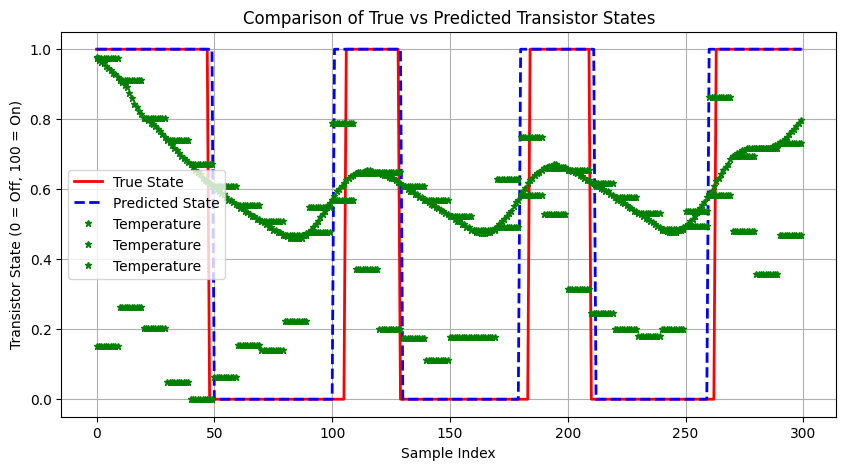

In [6]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression()
logistic_model.fit(XA, yA)

# Predecir los estados del transistor
y_pred = logistic_model.predict(XB)


# Graficar los datos reales
plt.figure(figsize=(10,5))
plt.plot(range(len(yB)), yB, 'r-', label='True State', linewidth=2)
plt.plot(range(len(y_pred)), y_pred, 'b--', label='Predicted State', linewidth=2)
plt.plot(range(len(XB)), XB, '*g', label='Temperature', markersize=5)
plt.title('Comparison of True vs Predicted Transistor States')
plt.xlabel('Sample Index')
plt.ylabel('Transistor State (0 = Off, 100 = On)')
plt.legend()
plt.grid()
plt.show()


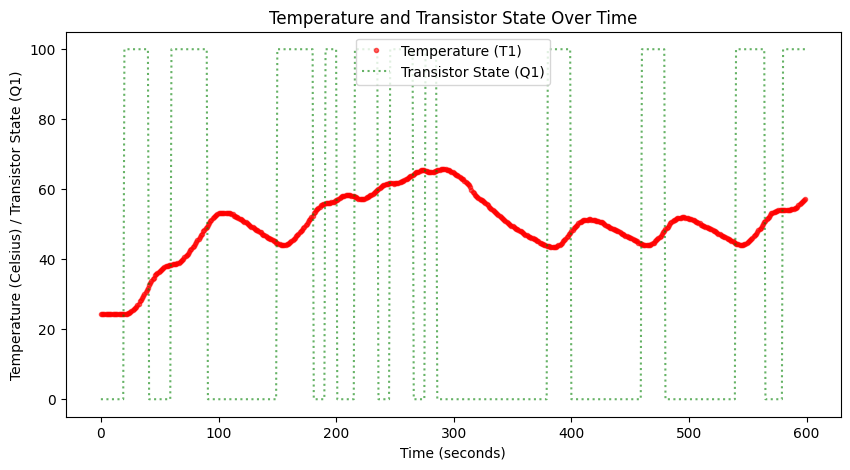

In [7]:
time = data['Time'].values
plt.figure(figsize=(10,5))
plt.plot(time, Temp, '.r', label='Temperature (T1)', alpha=0.6)
plt.plot(time, State, ':g', label='Transistor State (Q1)', alpha=0.6)
plt.title('Temperature and Transistor State Over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Temperature (Celsius) / Transistor State (Q1)')
plt.legend()
plt.show()